**step-1: Import the packages**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**step-2 : Read visa datasets**

In [13]:
file_path=r'C:\Naresh IT\Datasets\Visa_Predection_Dataset.csv'
visa_df=pd.read_csv(file_path)

**step-3 : Divide into categorical and Numerical columns**

In [18]:
visa_df.dtypes.to_dict() #column to datatype

{'case_id': dtype('O'),
 'continent': dtype('O'),
 'education_of_employee': dtype('O'),
 'has_job_experience': dtype('O'),
 'requires_job_training': dtype('O'),
 'no_of_employees': dtype('int64'),
 'yr_of_estab': dtype('int64'),
 'region_of_employment': dtype('O'),
 'prevailing_wage': dtype('float64'),
 'unit_of_wage': dtype('O'),
 'full_time_position': dtype('O'),
 'case_status': dtype('O')}

In [22]:
types=visa_df.dtypes.to_dict()
cat=[i for i,j in types.items() if j=='object']
num=[i for i,j in types.items() if j!='object']

In [24]:
len(cat),len(num)

(9, 3)

In [28]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns # the above nad this serves the same 
#this is shortcut

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path=r'C:\Naresh IT\Datasets\Visa_Predection_Dataset.csv'
visa_df=pd.read_csv(file_path)

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns # the above nad this serves the same 
#this is shortcut

**step-4 : How to read a column**

In [33]:
visa_df['continent'] #if we do spell mistakes key error will come because python is case 
#sensitive

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [35]:
# visa_df['continent']
# visa_df[['continent']]
cols=['continent','case_status']
visa_df[cols]

,continent,case_status
0,Asia,Denied
1,Asia,Certified
2,Asia,Denied
3,Asia,Denied
4,Africa,Certified
...,...,...
25475,Asia,Certified
25476,Asia,Certified
25477,Asia,Certified
25478,Asia,Certified


In [53]:
visa_df['continent']
visa_df[['continent']]
visa_df.loc[:,'continent']



0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [55]:
visa_df.loc[:,['continent']]



,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


In [63]:
Id=cat.get_loc('continent')


In [65]:

visa_df.iloc[:,Id]


0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [67]:
visa_df.iloc[:,[Id]]

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


**continent column analysis**

In [ ]:
visa_df['continent'] #series
visa_df[['continent']] #dataframe


In [72]:
visa_df['continent'].values

array(['Asia', 'Asia', 'Asia', ..., 'Asia', 'Asia', 'Asia'], dtype=object)

In [74]:
len(visa_df['continent'].values)

25480

**unique**

In [78]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [80]:
visa_df['continent'].nunique()

6

In [ ]:
**TASK:**

- we want to know how many asia applicants are from total data

In [86]:
visa_df
visa_df['continent']
con=visa_df['continent']=='Asia' #condition
len(visa_df[con])

16861

In [88]:
con=visa_df['continent']=='Asia'
con=visa_df['continent']=='Asia'
con=visa_df['continent']=='Asia'
con=visa_df['continent']=='Asia'
con=visa_df['continent']=='Asia'
con=visa_df['continent']=='Asia'

# take a empty list
# apply for loop
con=visa_df['continent']==i
len(visa_df[con])

NameError: name 'i' is not defined

In [90]:
labels=visa_df['continent'].unique()
for i in labels:
    print(i)

Asia
Africa
North America
Europe
South America
Oceania


In [92]:
l=[]
labels=visa_df['continent'].unique()
for i in labels:
    con=visa_df['continent']==i
    count=len(visa_df[con])
    l.append(count)

In [94]:
l

[16861, 551, 3292, 3732, 852, 192]

In [96]:
labels

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [98]:
continent_df=pd.DataFrame(zip(labels,l),
             columns=['continent','Number of Applicants'])
continent_df

,continent,Number of Applicants
0,Asia,16861
1,Africa,551
2,North America,3292
3,Europe,3732
4,South America,852
5,Oceania,192


In [106]:
continent_df.to_csv('continent_data',index=False) #continent_Data will be name of the csv file

**Value counts**

In [108]:
#Frequency table
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [121]:
visa_df['continent'].value_counts().index

Index(['Asia', 'Europe', 'North America', 'South America', 'Africa',
       'Oceania'],
      dtype='object', name='continent')

In [115]:
visa_df['continent'].value_counts().values

array([16861,  3732,  3292,   852,   551,   192], dtype=int64)

In [123]:
visa_df['continent'].value_counts()
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
pd.DataFrame(zip(keys,values),
             columns=['continent','Number of applicants'])


,continent,Number of applicants
0,Asia,16861
1,Europe,3732
2,North America,3292
3,South America,852
4,Africa,551
5,Oceania,192


**dont work on caseid:25480**

**Bar chart**

<BarContainer object of 6 artists>

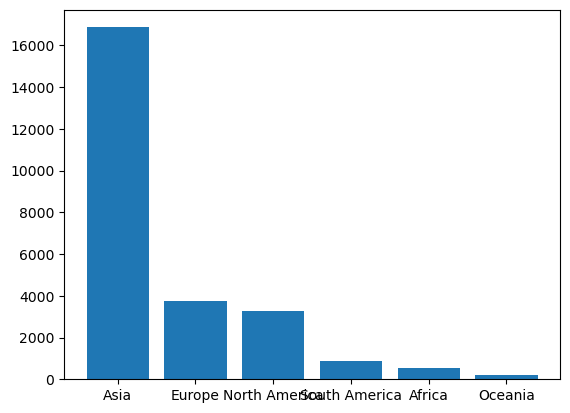

In [127]:
plt.bar(keys,values)

<BarContainer object of 6 artists>

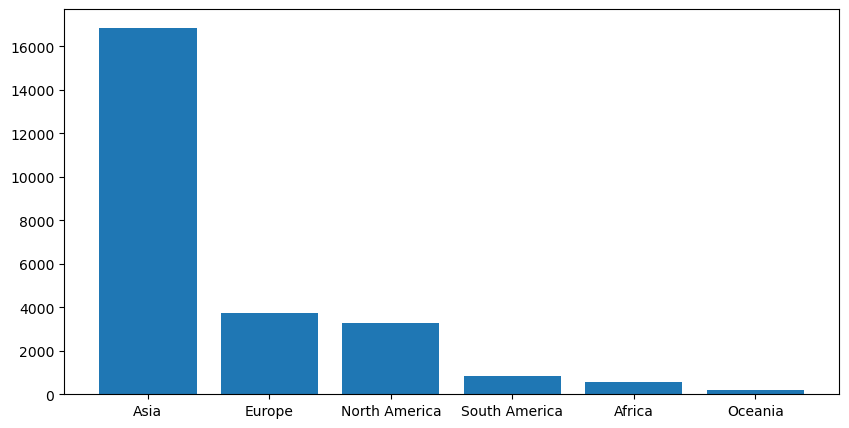

In [135]:
plt.figure(figsize=(10,5))
plt.bar(keys,values)

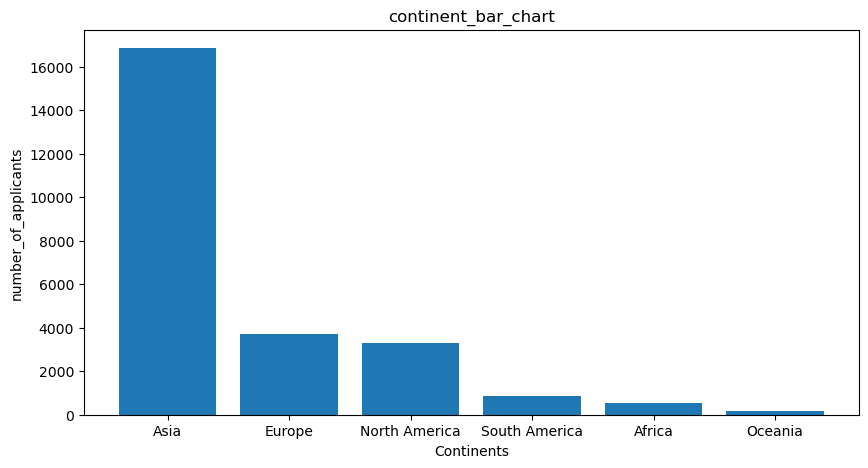

In [143]:
plt.figure(figsize=(10,5))
plt.bar(keys,values)
plt.xlabel('Continents')
plt.ylabel('number_of_applicants')
plt.title('continent_bar_chart')
plt.savefig('continent_bar_chart.jpg')
plt.show()

- we completed frequency table
- we completed bar chart
- if i want to draw mulitlpe plots we can use concept subplot1m

<Axes: >

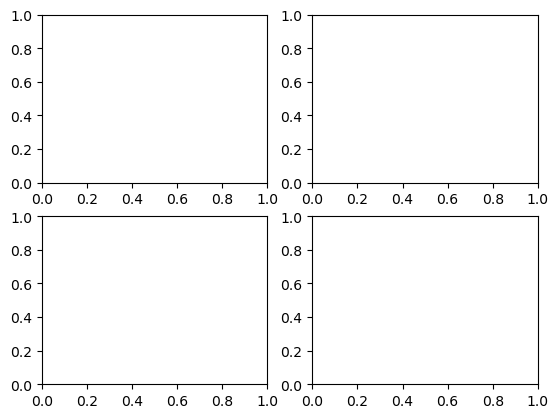

In [150]:
plt.subplot(2,2,1)
plt.subplot(2,2,2)
plt.subplot(2,2,3)
plt.subplot(2,2,4)

In [152]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [154]:
cat[1:]

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

<BarContainer object of 6 artists>

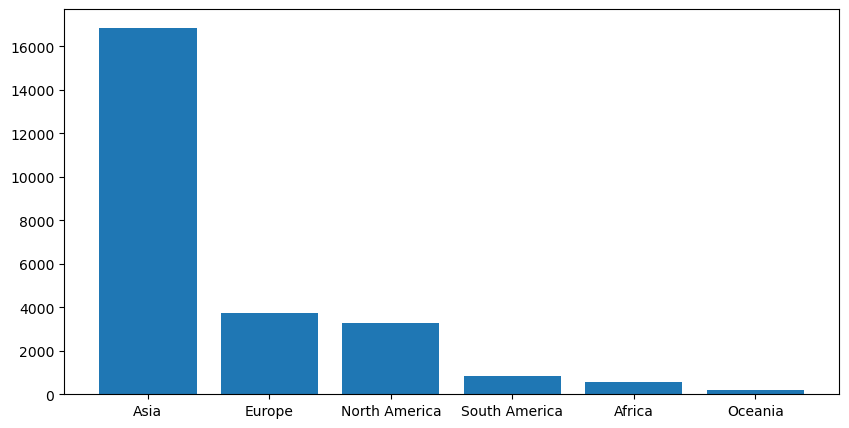

In [158]:
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values
plt.figure(figsize=(10,5))
plt.bar(keys,values)


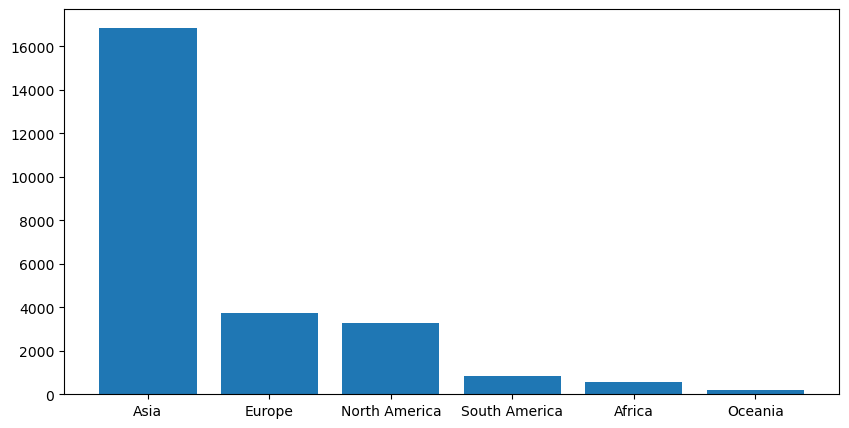

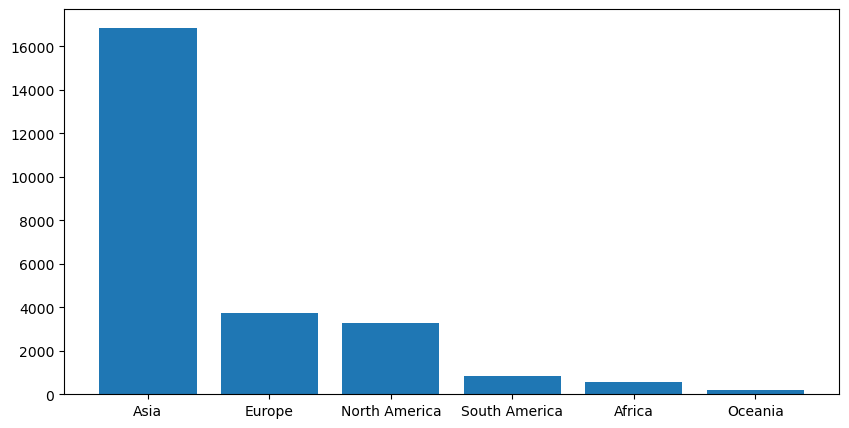

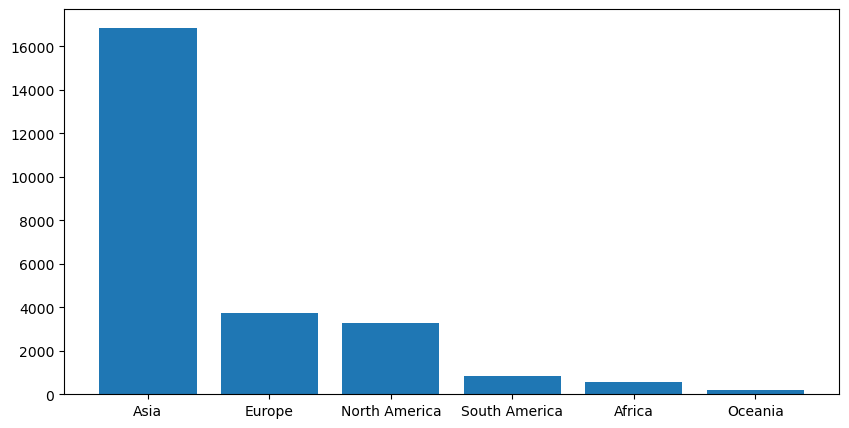

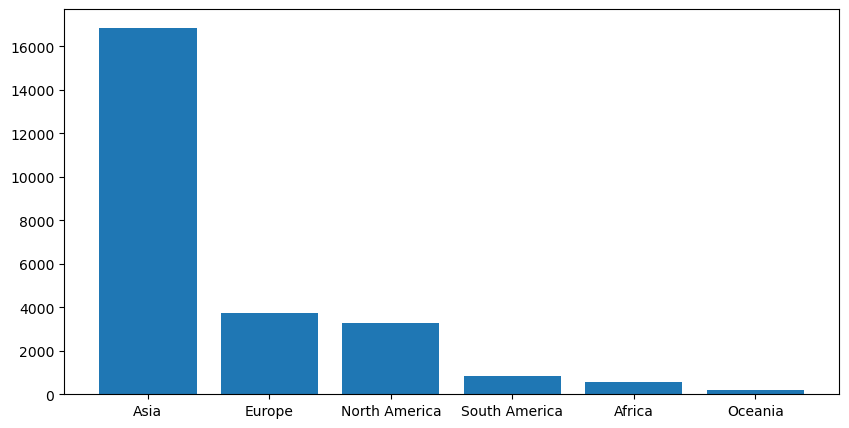

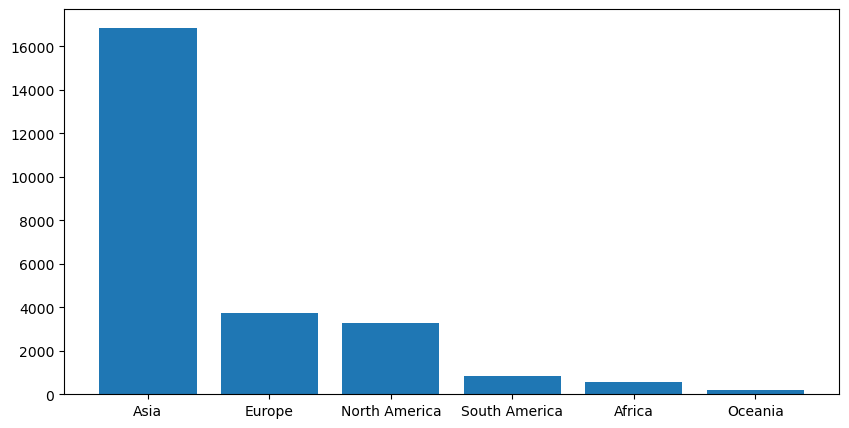

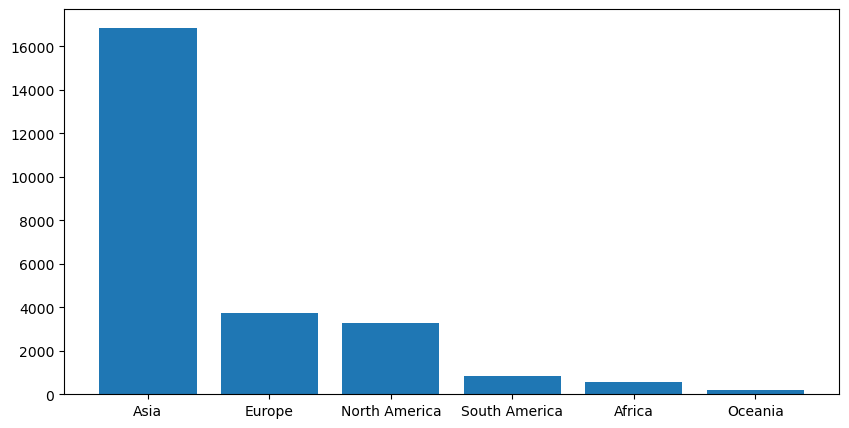

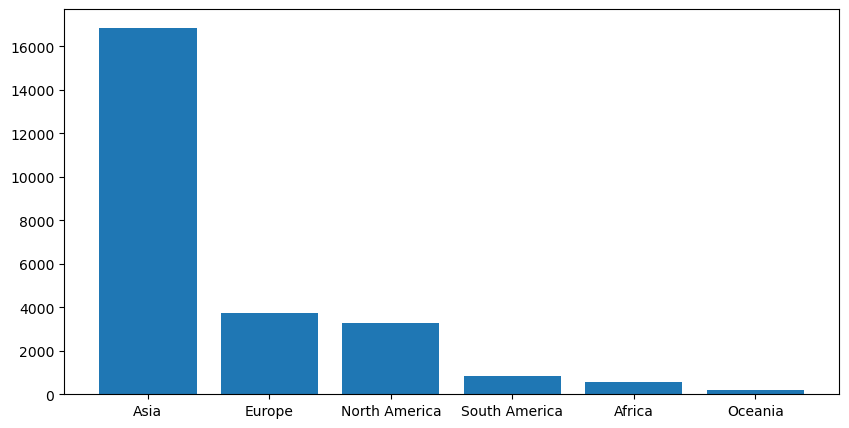

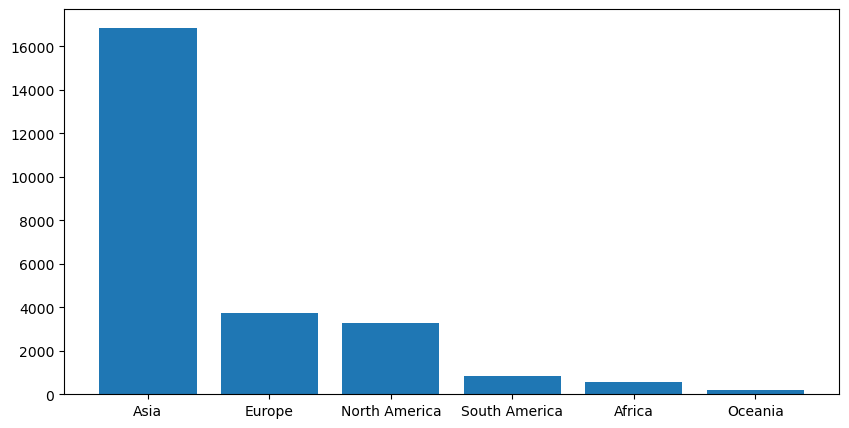

In [160]:
for i in cat[1:]:
    keys=visa_df['continent'].value_counts().keys()
    values=visa_df['continent'].value_counts().values
    plt.figure(figsize=(10,5))
    plt.bar(keys,values)

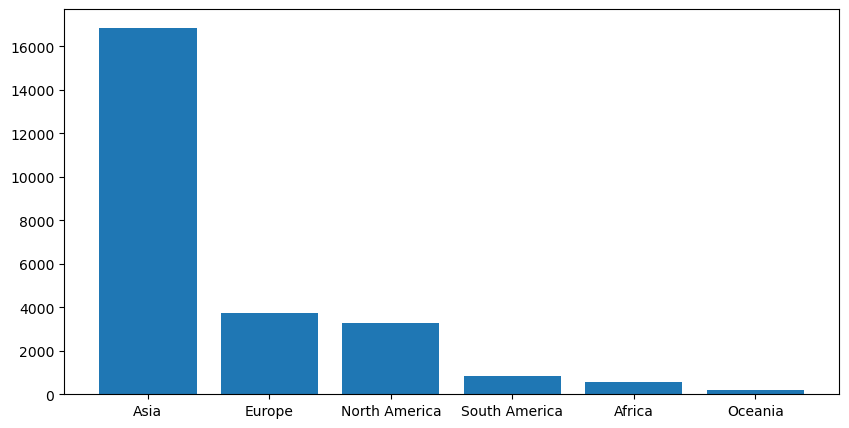

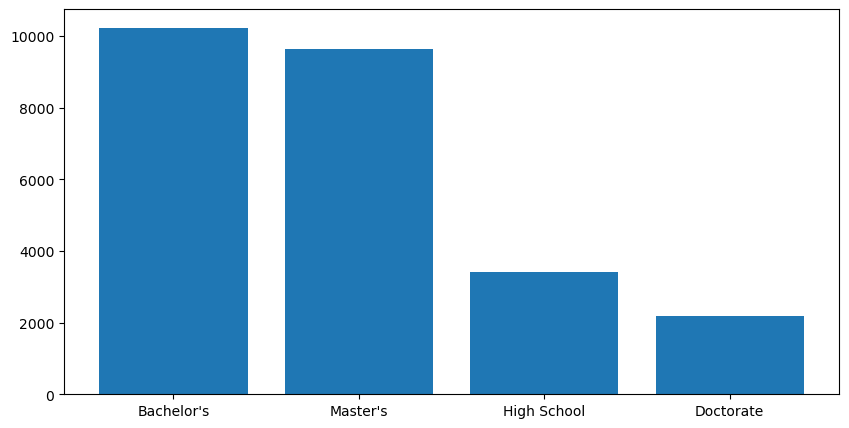

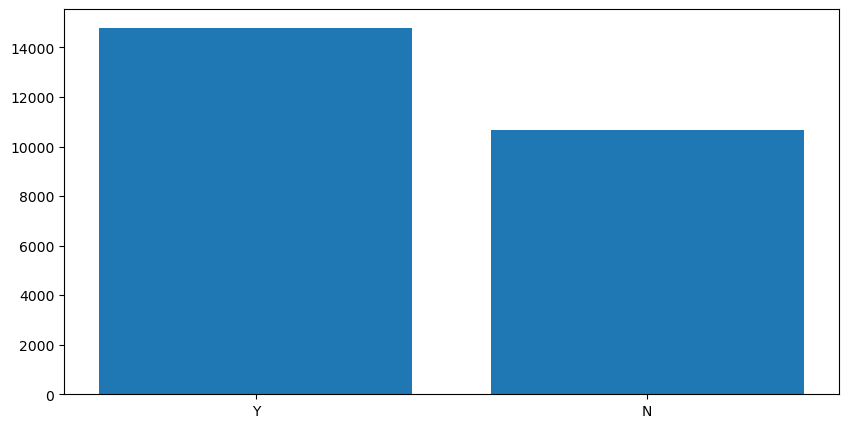

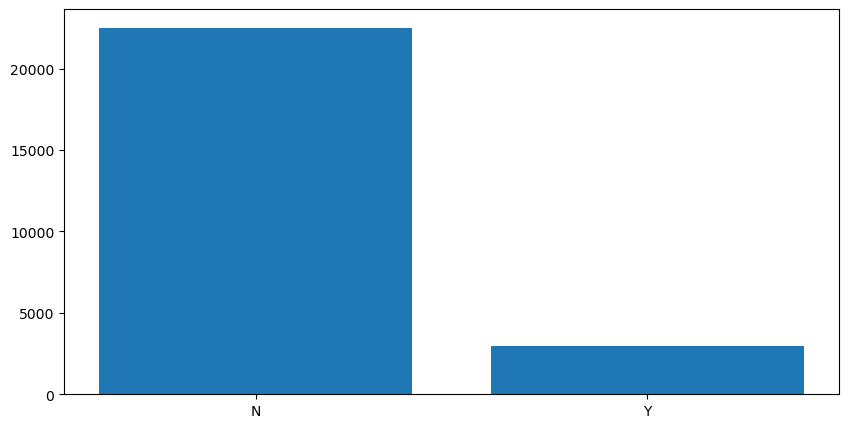

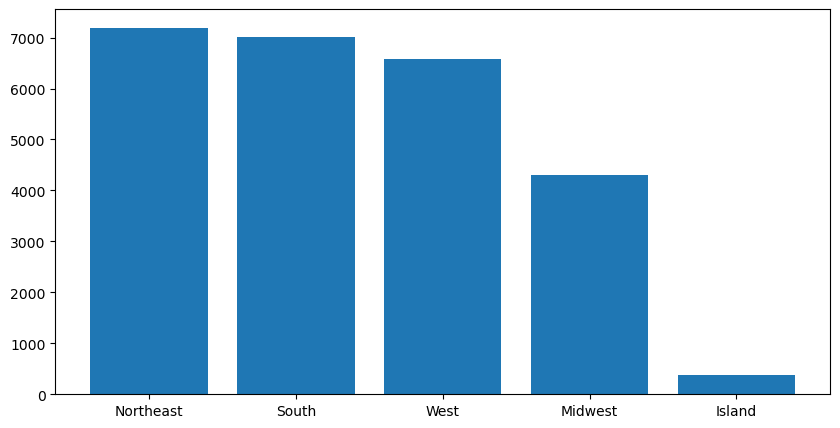

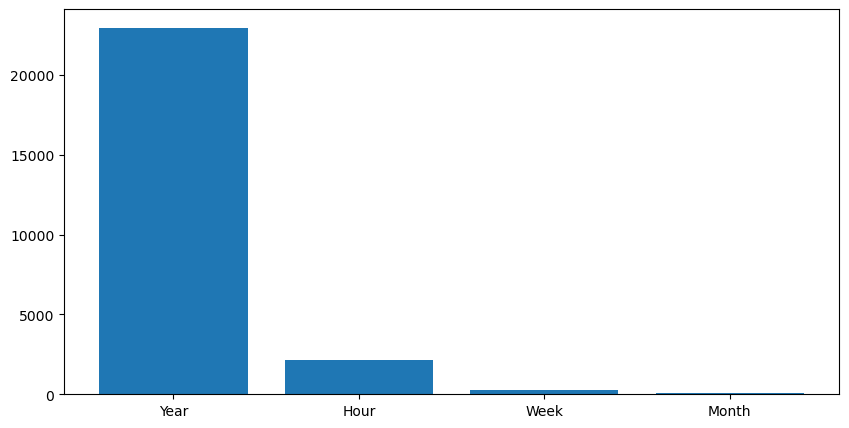

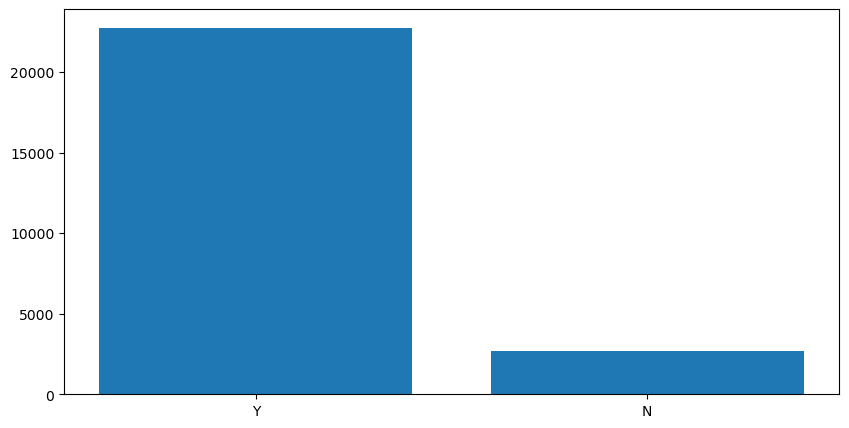

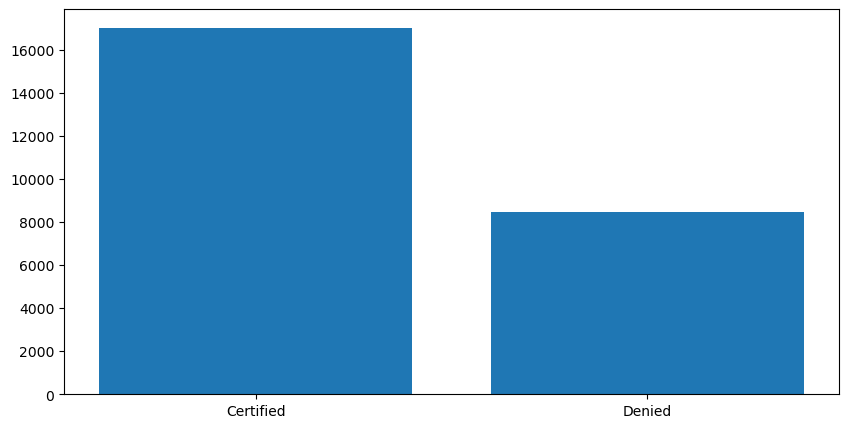

In [164]:
for i in cat[1:]:
    keys=visa_df[i].value_counts().keys()
    values=visa_df[i].value_counts().values
    plt.figure(figsize=(10,5))
    plt.bar(keys,values)

In [ ]:
plt.subplot(3,3,1)
plt.subplot(3,3,2)

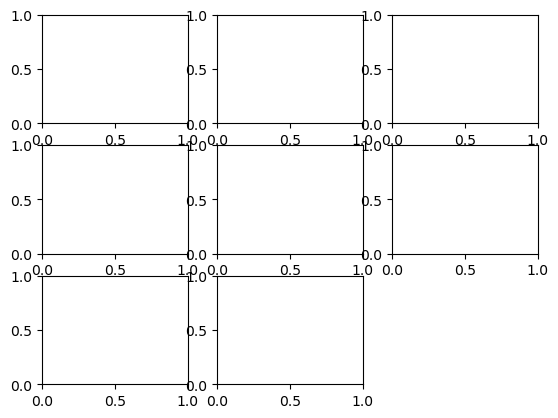

In [168]:
for i in range(1,9):
    plt.subplot(3,3,i)

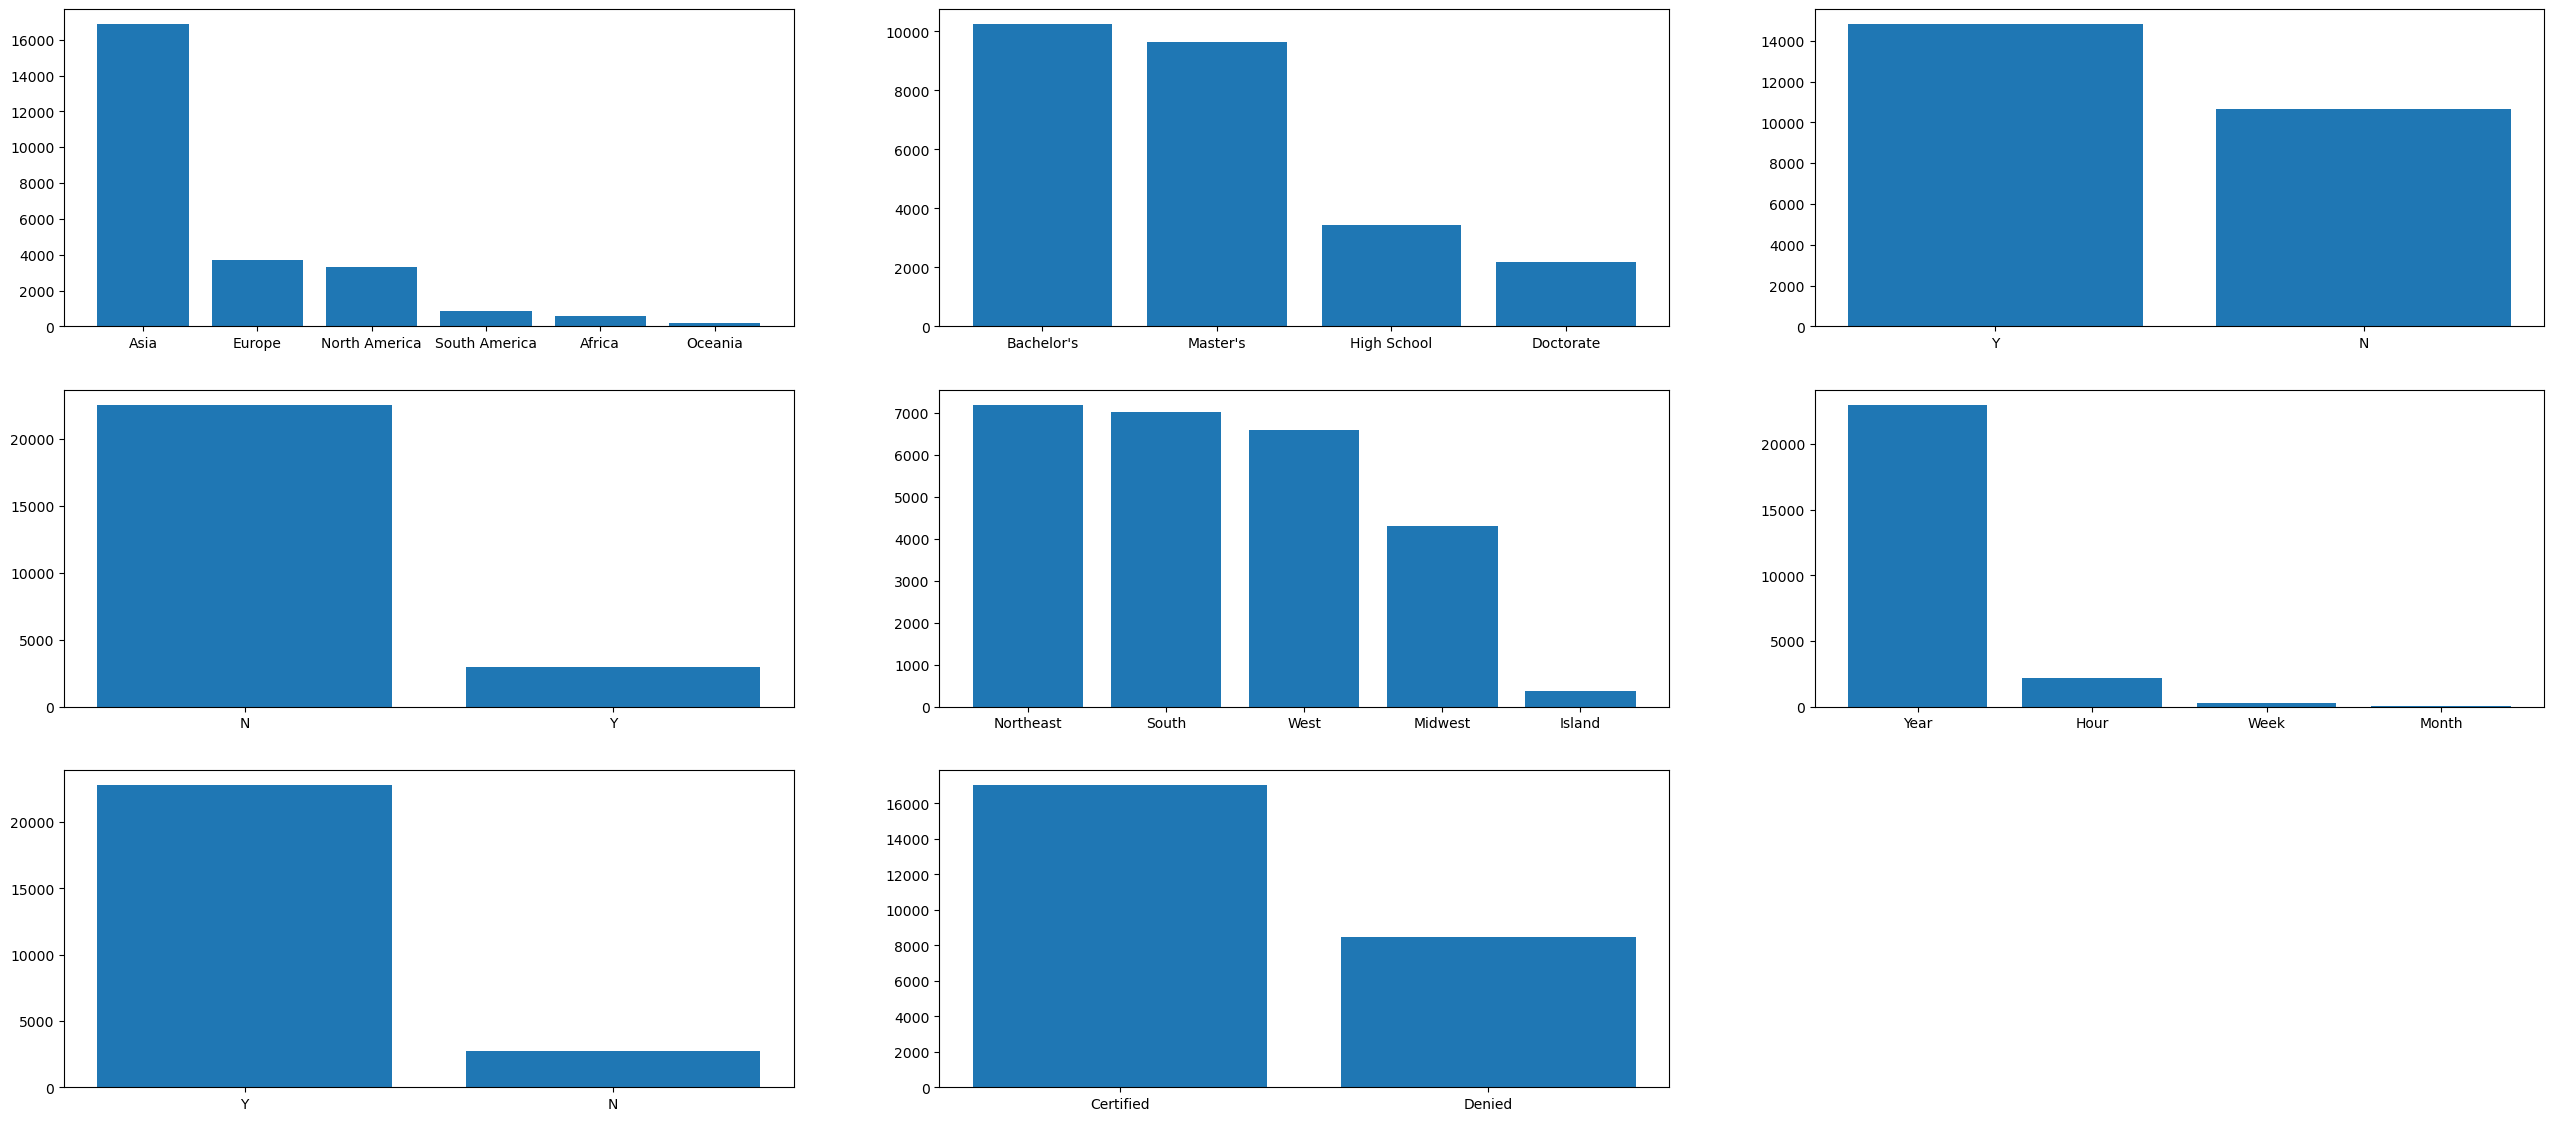

In [174]:
 plt.figure(figsize=(32,14))
for i in range(1,9):
    keys=visa_df[cat[i]].value_counts().keys()
    values=visa_df[cat[i]].value_counts().values
   
    plt.subplot(3,3,i)
    plt.bar(keys,values)


   

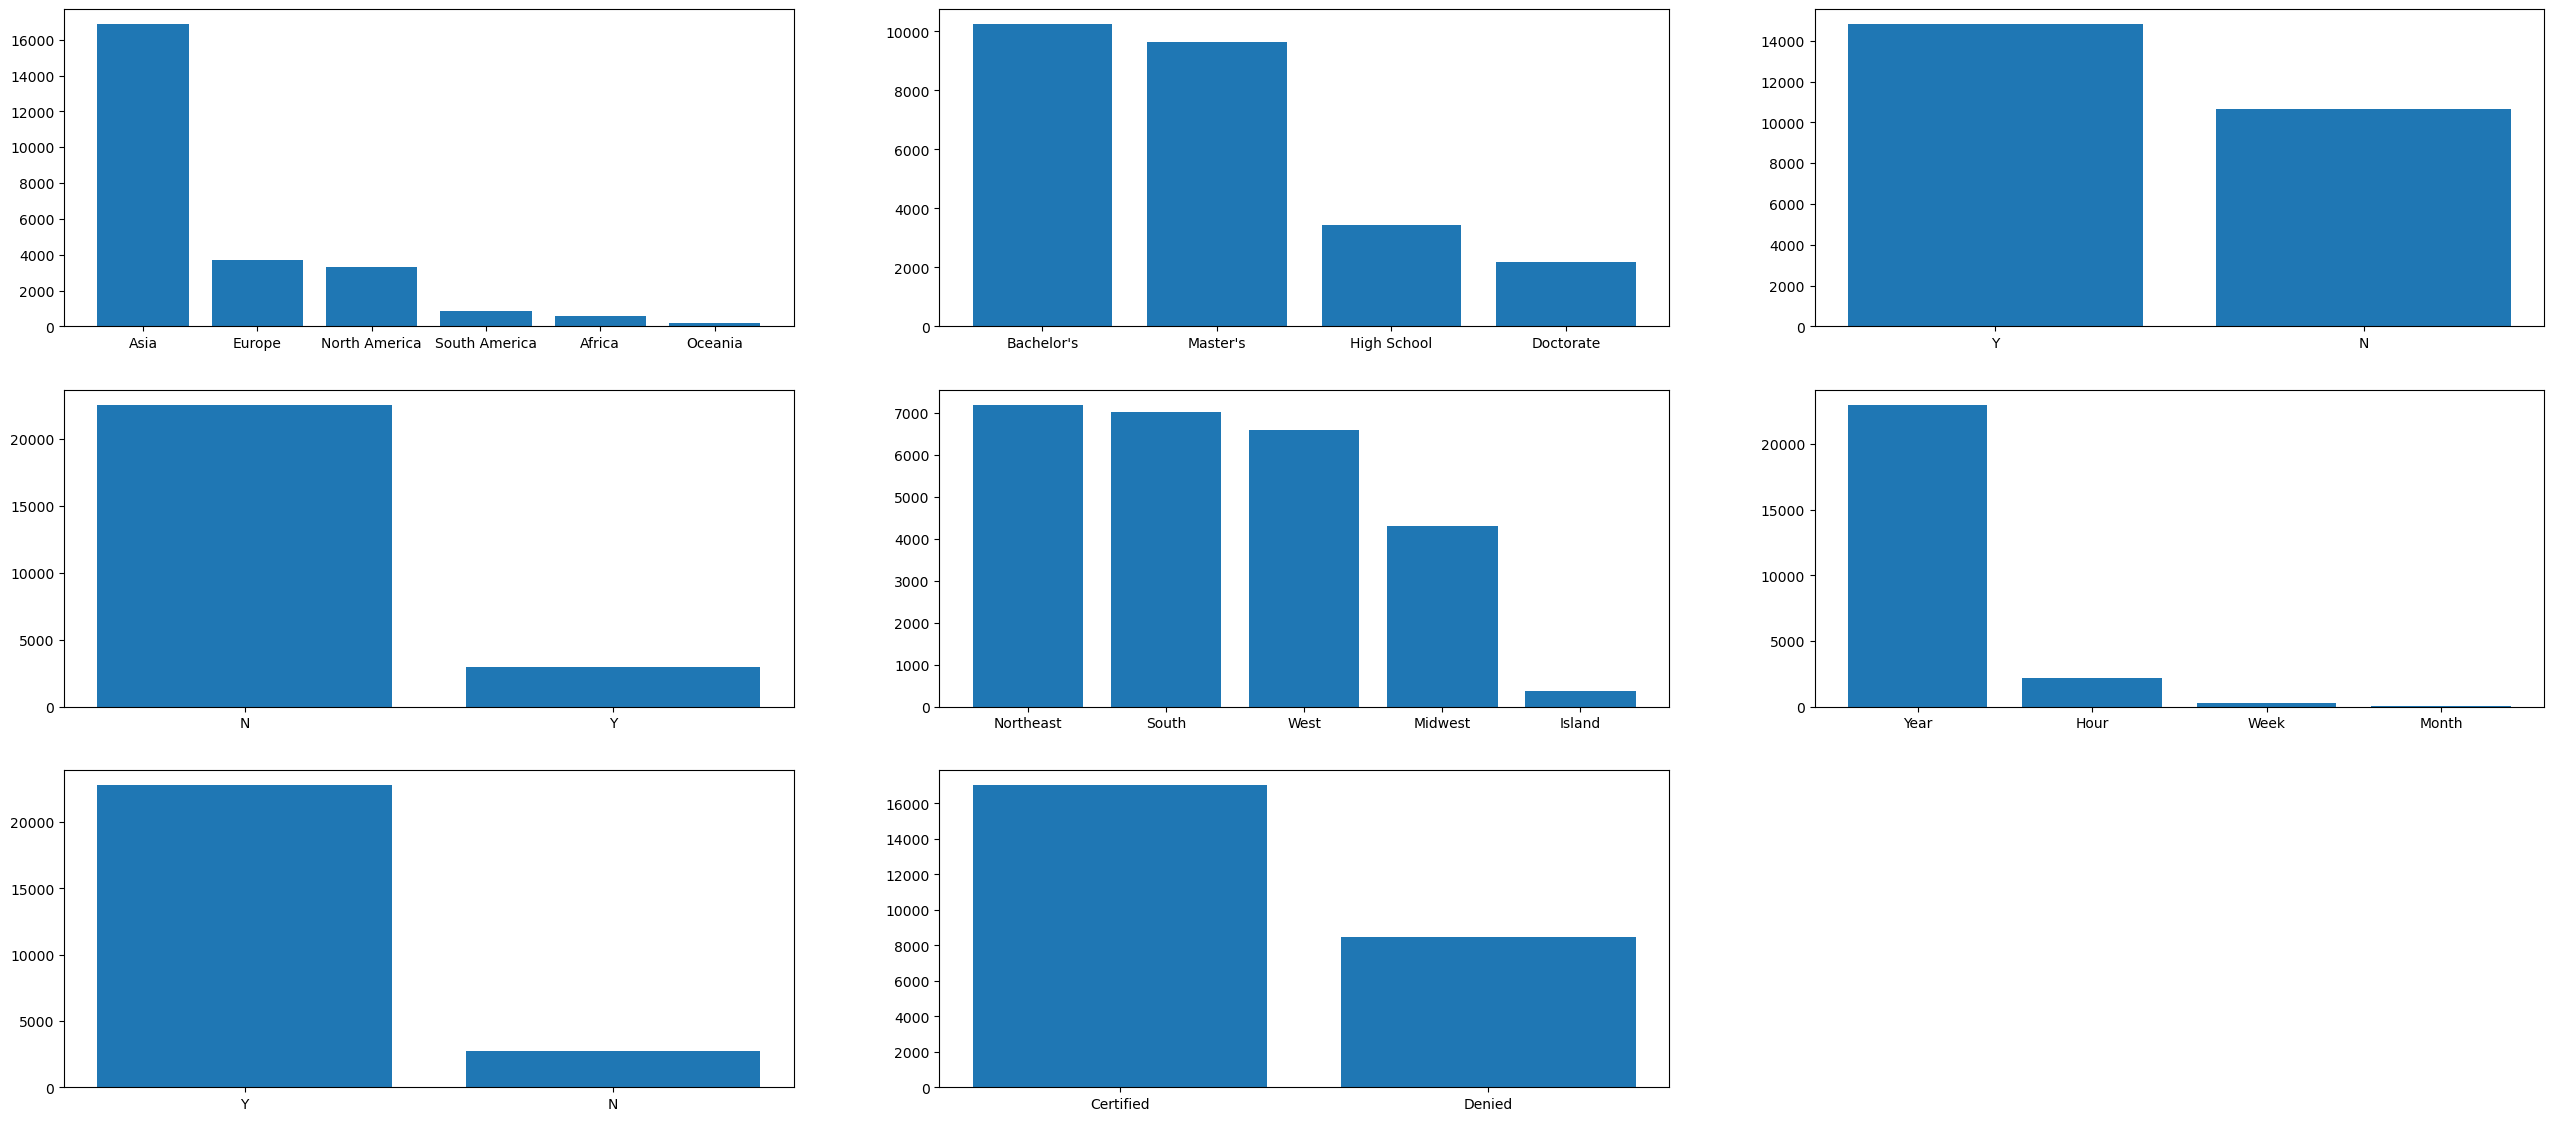

In [176]:
plt.figure(figsize=(32,14))
for i in range(1,9):
    keys=visa_df[cat[i]].value_counts().keys()
    values=visa_df[cat[i]].value_counts().values
   
    plt.subplot(3,3,i).bar(keys,values)

**pie chart**

In [179]:
visa_df['continent'].value_counts(normalize=True)

continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64

In [193]:
keys=visa_df['continent'].value_counts().keys()
values=visa_df['continent'].value_counts().values

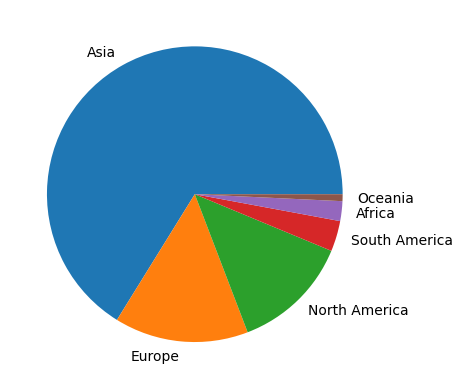

In [195]:
plt.pie(values,labels=keys)
plt.show()

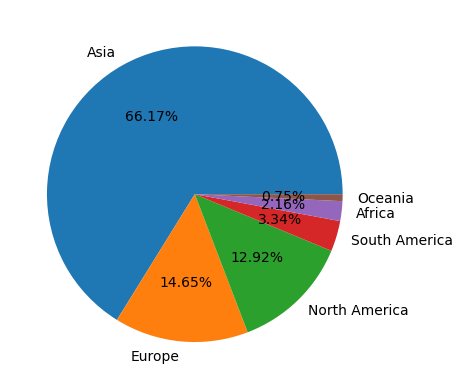

In [197]:
plt.pie(values,labels=keys,autopct="%0.2f%%")
plt.show()

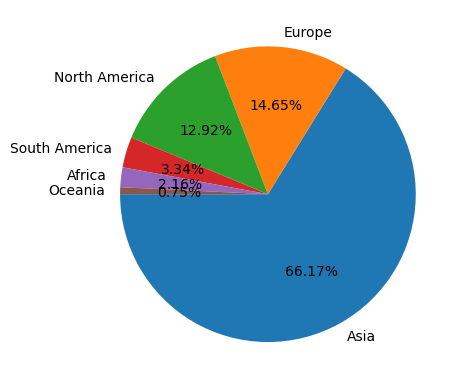

In [201]:
plt.pie(values,labels=keys,autopct="%0.2f%%",startangle=180)
plt.show()

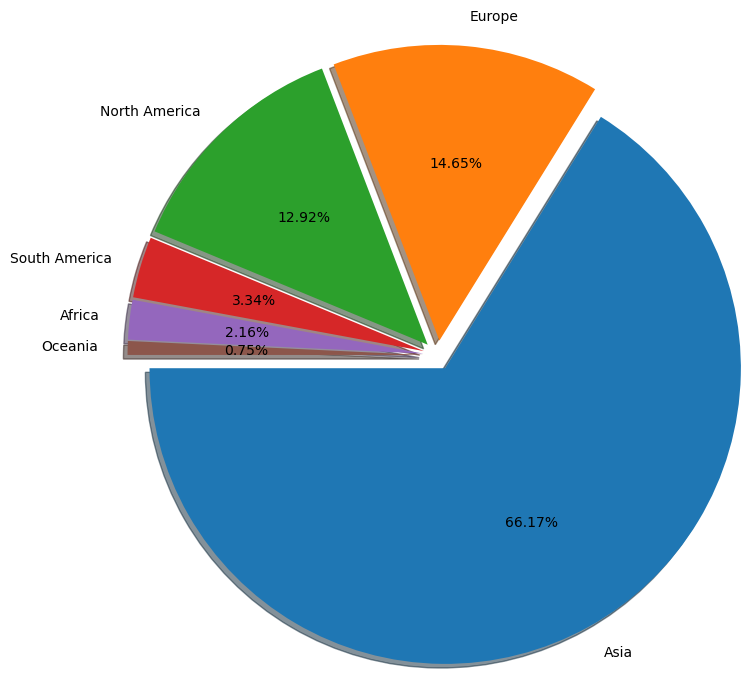

In [211]:
plt.pie(values,
        labels=keys,
        explode=[0.1 for i in range(6)],
        autopct="%0.2f%%",
        shadow=True,
        startangle=180,
        radius=2)
plt.show()